In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Read the cleaned file
df = pd.read_csv('../data/mudah-apartment-kl-selangor-cleaned.csv')
df.head()

,ads_id,prop_name,completion_year,monthly_rent,location,property_type,rooms,parking,bathroom,size (sq.ft),furnished,facilities,additional_facilities,region,facilities_count,additional_facilities_count
0,100323185,The Hipster @ Taman Desa,2022,4200,Kuala Lumpur - Taman Desa,Condominium,5,2,6,1842,Fully Furnished,"Minimart, Gymnasium, Security, Playground, Swi...","Air-Cond, Cooking Allowed, Washing Machine",Kuala Lumpur,10,3
1,100203973,Segar Courts,2017,2300,Kuala Lumpur - Cheras,Condominium,3,1,2,1170,Partially Furnished,"Playground, Parking, Barbeque area, Security, ...","Air-Cond, Cooking Allowed, Near KTM/LRT",Kuala Lumpur,9,3
2,100323128,Pangsapuri Teratak Muhibbah 2,2017,1000,Kuala Lumpur - Taman Desa,Apartment,3,0,2,650,Fully Furnished,"Minimart, Jogging Track, Lift, Swimming Pool",NaN,Kuala Lumpur,4,0
3,100191767,Sentul Point Suite Apartment,2020,1700,Kuala Lumpur - Sentul,Apartment,2,1,2,743,Partially Furnished,"Parking, Playground, Swimming Pool, Squash Cou...","Cooking Allowed, Near KTM/LRT, Washing Machine",Kuala Lumpur,8,3
4,97022692,Arte Mont Kiara,2017,1299,Kuala Lumpur - Mont Kiara,Service Residence,1,1,1,494,Not Furnished,"Parking, Security, Lift, Swimming Pool, Playgr...",Air-Cond,Kuala Lumpur,11,1


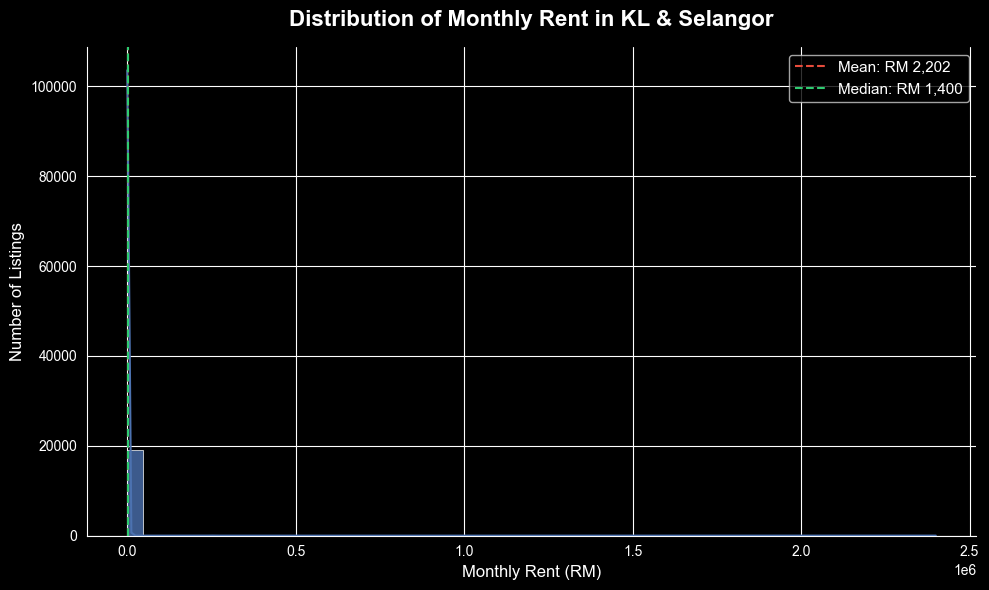

In [3]:
# Plot Histogram - Monthly Rent Distribution
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    df["monthly_rent"],
    bins=50,
    kde=True,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.8,
    ax=ax
)

# Styling
ax.set_title("Distribution of Monthly Rent in KL & Selangor", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Monthly Rent (RM)", fontsize=12)
ax.set_ylabel("Number of Listings", fontsize=12)
ax.tick_params(labelsize=10)

# Add mean and median lines
mean_rent = df["monthly_rent"].mean()
median_rent = df["monthly_rent"].median()
ax.axvline(mean_rent, color="#E74C3C", linestyle="--", linewidth=1.5, label=f"Mean: RM {mean_rent:,.0f}")
ax.axvline(median_rent, color="#2ECC71", linestyle="--", linewidth=1.5, label=f"Median: RM {median_rent:,.0f}")

ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

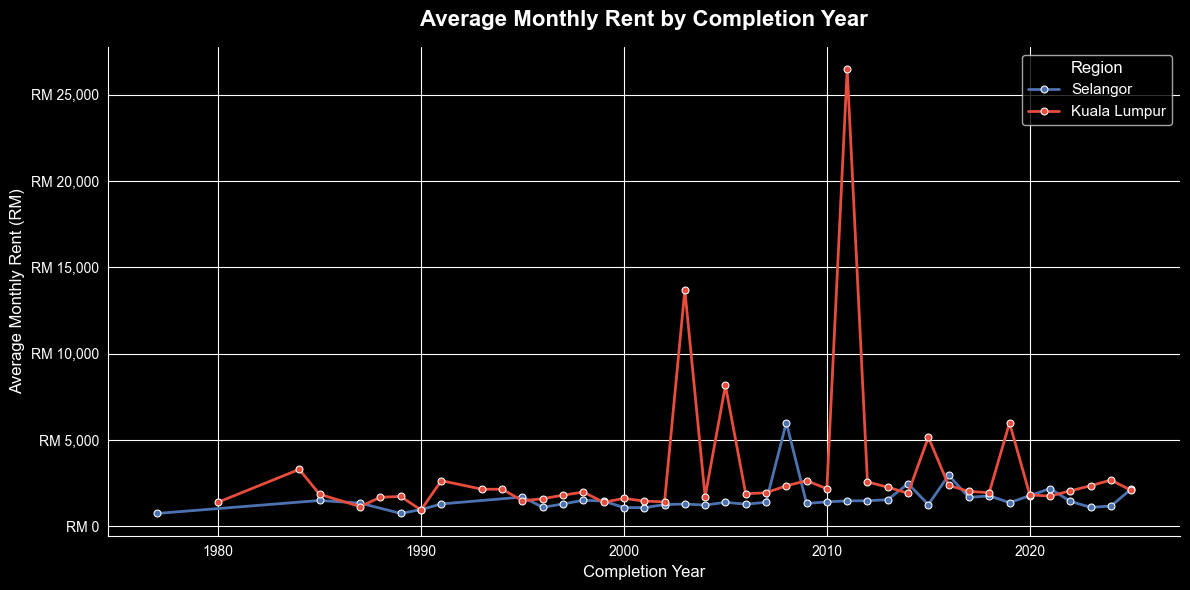

In [4]:
# Line Chart - Average Monthly Rent by Completion Year (per Region)

def average_monthly_rent_by_completion_year_per_region():
    avg_rent_by_year = df.groupby(["completion_year", "region"])["monthly_rent"].mean().reset_index()

    fig, ax = plt.subplots(figsize=(12, 6))

    sns.lineplot(
        data=avg_rent_by_year,
        x="completion_year",
        y="monthly_rent",
        hue="region",
        marker="o",
        markersize=5,
        linewidth=2,
        palette={"Kuala Lumpur": "#E74C3C", "Selangor": "#4C72B0"},
        ax=ax
    )

    # Styling
    ax.set_title("Average Monthly Rent by Completion Year", fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel("Completion Year", fontsize=12)
    ax.set_ylabel("Average Monthly Rent (RM)", fontsize=12)
    ax.tick_params(labelsize=10)
    ax.legend(title="Region", fontsize=11, title_fontsize=12)

    # Format y-axis with RM
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"RM {x:,.0f}"))

    sns.despine()
    plt.tight_layout()
    plt.show()

average_monthly_rent_by_completion_year_per_region()